In [1]:
import torch, sys, os
sys.path.insert(0, os.path.abspath(".."))   # ml/ root in path

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM    : {mem:.1f} GB")

Python  : 3.10.11
PyTorch : 2.5.1+cu121
CUDA    : True
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM    : 6.0 GB


In [2]:
import config

paths_to_check = {
    "DATASET folder" : config.DATASET_DIR,
    "train_split.csv": config.TRAIN_CSV,
    "test_split.csv" : config.TEST_CSV,
    "Skin_Metadata"  : config.METADATA_CSV,
}

for name, path in paths_to_check.items():
    status = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"{status}  {name:20s}  →  {path}")

✅  DATASET folder        →  d:\dermasense-web\ml\data\raw\DATASET\DATASET_0\DATASET_0
✅  train_split.csv       →  d:\dermasense-web\ml\data\raw\train_split.csv
✅  test_split.csv        →  d:\dermasense-web\ml\data\raw\test_split.csv
✅  Skin_Metadata         →  d:\dermasense-web\ml\data\raw\Skin_Metadata.csv


In [3]:
import pandas as pd

train_df = pd.read_csv(config.TRAIN_CSV)
test_df  = pd.read_csv(config.TEST_CSV)
meta_df  = pd.read_csv(config.METADATA_CSV)

print(f"Train rows : {len(train_df)}")
print(f"Test  rows : {len(test_df)}")
print(f"Metadata   : {len(meta_df)}")
print("\n── Train Columns ──")
print(train_df.columns.tolist())
print("\n── Train Sample ──")
train_df.head(3)

Train rows : 4399
Test  rows : 1051
Metadata   : 5450

── Train Columns ──
['Age', 'Body_part_Armpits (Axillary Region)', 'Body_part_Back', 'Body_part_Back of the Knees (Popliteal Region)', 'Body_part_Breasts (Mammary Region)', 'Body_part_Calves (Sural Region)', 'Body_part_Genital Area (Pubic Region)', 'Body_part_Groin (Inguinal Region)', 'Body_part_Head Cheeks', 'Body_part_Head Chin', 'Body_part_Head Ears', 'Body_part_Head Eye', 'Body_part_Head Forehead', 'Body_part_Head Lips', 'Body_part_Head Nose', 'Body_part_Head Scalp', 'Body_part_Head Temples', 'Body_part_Lower Extremities Ankles (Tarsal Region)', 'Body_part_Lower Extremities Feet (Pedal Region)', 'Body_part_Lower Extremities Feet (Pedal Region) Toes (Digits)', 'Body_part_Lower Extremities Hips (Coxal Region)', 'Body_part_Lower Extremities Knees (Patellar Region)', 'Body_part_Lower Extremities Lower Legs', 'Body_part_Lower Extremities Lower Legs (Crural Region)', 'Body_part_Lower Extremities Soles (Plantar Region)', 'Body_part_Lo

,Age,Body_part_Armpits (Axillary Region),Body_part_Back,Body_part_Back of the Knees (Popliteal Region),Body_part_Breasts (Mammary Region),Body_part_Calves (Sural Region),Body_part_Genital Area (Pubic Region),Body_part_Groin (Inguinal Region),Body_part_Head Cheeks,Body_part_Head Chin,...,Disease_label,Fitzpatrick,Gradability,Image_name,Main_class,Monk_skin_tone,Quality,Sex,Sub_class,Subject_ID
0,10 - 20,0,0,0,0,0,0,1,0,0,...,Steroid Modified Tinea,FST 3,Yes,IMG_0002.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
1,10 - 20,0,0,0,0,0,0,1,0,0,...,Steroid Modified Tinea,FST 3,Yes,IMG_0005.jpg,Infectious Disorders,MST 5,"Yes, the quality is sufficient for me or anoth...",Male,Infectious skin conditions -Fungal,SUB00001
2,40 - 60,0,0,0,0,0,0,0,1,0,...,Acne,FST 4,Yes,IMG_0009.jpg,Skin Appendages Disorders,MST 6,"Yes, the quality is sufficient for me or anoth...",Female,Sebacious Glands and Acneiform Disorders,SUB00002


In [4]:
import matplotlib.pyplot as plt

label_col    = "Disease_label"
main_col     = "Main_class"
img_col      = "Image_name"

# Disease distribution
vc = train_df[label_col].value_counts()
print(f"Total unique diseases : {vc.shape[0]}")
print(f"Total Main classes    : {train_df[main_col].nunique()}")
print(f"\nTop 10 diseases:\n{vc.head(10)}")
print(f"\nMain class distribution:\n{train_df[main_col].value_counts()}")

Total unique diseases : 233
Total Main classes    : 8

Top 10 diseases:
Disease_label
Vitiligo                  490
Tinea Cruris              435
Tinea Corporis            271
Acne                      148
Scabies                   142
Eczema                    130
Psoriasis                 126
Tinea Faciei              112
Contact Dermatitis        108
Steroid Modified Tinea    100
Name: count, dtype: int64

Main class distribution:
Main_class
Infectious Disorders         1808
Inflammatory Disorders       1285
Pigmentary Disorders          667
Skin Appendages Disorders     379
Other skin disorders          131
Keratanisation Disorders       58
Neoplasms and tumors           40
No Definite Diagnosis          31
Name: count, dtype: int64


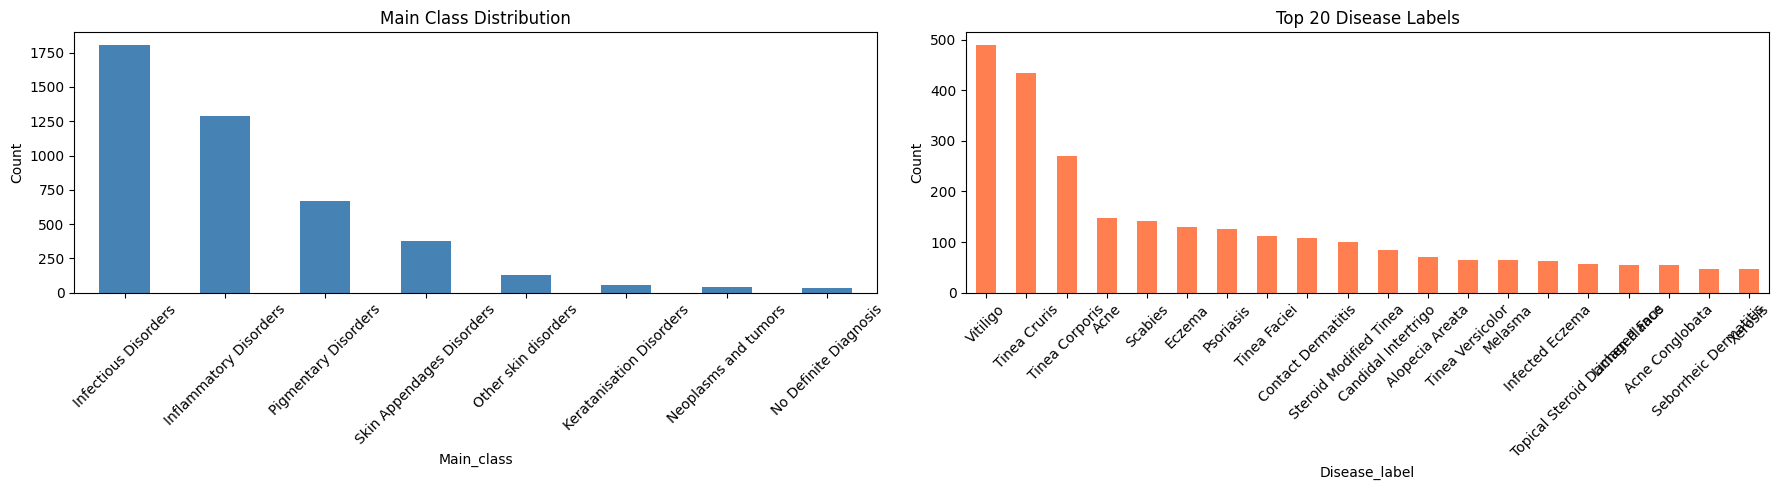

In [5]:
# Main class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: Main class
train_df[main_col].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", title="Main Class Distribution"
)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Top 20 diseases
vc.head(20).plot(
    kind="bar", ax=axes[1], color="coral", title="Top 20 Disease Labels"
)
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{config.PLOTS_DIR}/class_distribution.png", dpi=150)
plt.show()

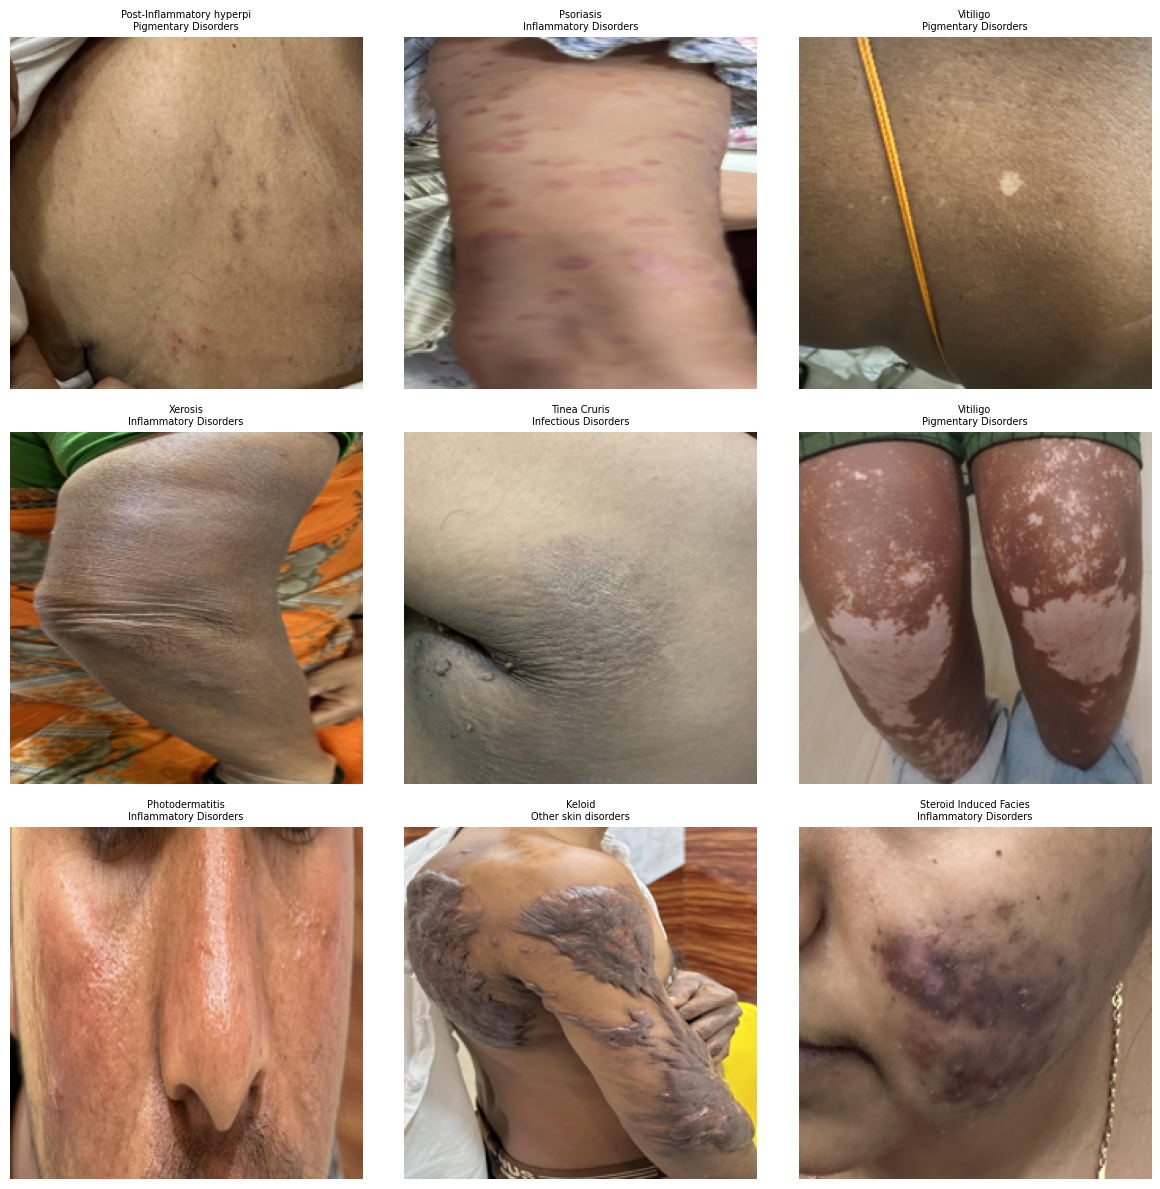

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from PIL import Image
import matplotlib.pyplot as plt
from dataset import find_image
import config

sample = train_df.sample(9, random_state=42).reset_index(drop=True)
EXTRA_DIRS = [config.DATASET_DIR_0, config.DATASET_DIR_1]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    row = sample.iloc[i]
    fname = str(row[config.IMG_COL])
    full_path = find_image(config.DATASET_DIR_0, fname, EXTRA_DIRS)
    if full_path:
        img = Image.open(full_path).convert("RGB").resize((224, 224))
        ax.imshow(img)
        title = f"{str(row[config.LABEL_COL])[:25]}\n{row[config.MAIN_CLASS_COL]}"
    else:
        ax.set_facecolor("lightcoral")
        title = f"NOT FOUND\n{fname}"
    ax.set_title(title, fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{config.PLOTS_DIR}/sample_images.png", dpi=150)
plt.show()

In [7]:
# Count available feature columns
body_cols      = [c for c in train_df.columns if c.startswith("Body_part_")]
descriptor_cols = [c for c in train_df.columns if c.startswith("Descriptor_")]

print(f"Body part features  : {len(body_cols)}")
print(f"Descriptor features : {len(descriptor_cols)}")
print(f"Total tabular feats : {len(body_cols) + len(descriptor_cols)}")

# Check missing values in key columns
key_cols = [label_col, main_col, img_col, "Fitzpatrick", "Age", "Sex"]
print("\n── Missing Values ──")
print(train_df[key_cols].isnull().sum())

# Check Image_name format (extension check)
print(f"\n── Sample Image Names ──")
print(train_df[img_col].head(5).tolist())

Body part features  : 49
Descriptor features : 47
Total tabular feats : 96

── Missing Values ──
Disease_label    0
Main_class       0
Image_name       0
Fitzpatrick      6
Age              0
Sex              0
dtype: int64

── Sample Image Names ──
['IMG_0002.jpg', 'IMG_0005.jpg', 'IMG_0009.jpg', 'IMG_0010.jpg', 'IMG_0011.jpg']


In [8]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

import importlib
import config
importlib.reload(config)

import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from dataset import DermaSenseDataset
from utils import get_label_map, set_seed

set_seed(config.SEED)

# ── Load CSVs ──────────────────────────────────────────────────────────────────
train_df = pd.read_csv(config.TRAIN_CSV)
test_df  = pd.read_csv(config.TEST_CSV)

# ── Remove rare classes (< 2 samples) ─────────────────────────────────────────
class_counts     = train_df[config.LABEL_COL].value_counts()
rare_classes     = class_counts[class_counts < 2].index.tolist()
train_df_filtered = train_df[~train_df[config.LABEL_COL].isin(rare_classes)].copy()
print(f"Classes  : {class_counts.shape[0]} total → {train_df_filtered[config.LABEL_COL].nunique()} after filter")
print(f"Rows     : {len(train_df)} → {len(train_df_filtered)} (removed {len(rare_classes)} rare classes)")

# ── Label map ─────────────────────────────────────────────────────────────────
l2i, i2l = get_label_map(train_df_filtered[config.LABEL_COL])
config.NUM_CLASSES = len(l2i)
print(f"NUM_CLASSES : {config.NUM_CLASSES}")

# ── Train / Val split ─────────────────────────────────────────────────────────
train_part, val_part = train_test_split(
    train_df_filtered,
    test_size=config.VAL_SPLIT,
    stratify=train_df_filtered[config.LABEL_COL],
    random_state=config.SEED
)
print(f"Train : {len(train_part)} | Val : {len(val_part)}")

# ── Image dirs — both DATASET_0 and DATASET_1 ─────────────────────────────────
EXTRA_DIRS = [config.DATASET_DIR_0, config.DATASET_DIR_1]

# ── Datasets ──────────────────────────────────────────────────────────────────
train_ds = DermaSenseDataset(
    train_part, config.DATASET_DIR_0, l2i,
    config.IMG_COL, config.LABEL_COL,
    config.IMG_SIZE, train=True,
    extra_dirs=EXTRA_DIRS
)
val_ds = DermaSenseDataset(
    val_part, config.DATASET_DIR_0, l2i,
    config.IMG_COL, config.LABEL_COL,
    config.IMG_SIZE, train=False,
    extra_dirs=EXTRA_DIRS
)
print(f"train_ds : {len(train_ds)} | val_ds : {len(val_ds)}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_ds, batch_size=config.BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=False
)
val_loader = DataLoader(
    val_ds, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=False
)

# ── Batch sanity check ────────────────────────────────────────────────────────
imgs, tabs, labels = next(iter(train_loader))
print(f"\n── Batch Shapes ──")
print(f"Images  : {imgs.shape}")    # (24, 3, 300, 300)
print(f"Tabular : {tabs.shape}")    # (24, 96)
print(f"Labels  : {labels.shape}")  # (24,)
print(f"dtype   : {imgs.dtype} | device: {imgs.device}")
print("\n✅ DataLoader working!")

Classes  : 233 total → 181 after filter
Rows     : 4399 → 4347 (removed 52 rare classes)
NUM_CLASSES : 181
Train : 3694 | Val : 653
train_ds : 3694 | val_ds : 653

── Batch Shapes ──
Images  : torch.Size([24, 3, 300, 300])
Tabular : torch.Size([24, 96])
Labels  : torch.Size([24])
dtype   : torch.float32 | device: cpu

✅ DataLoader working!


In [9]:
import torch
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

from model import build_model
import config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = build_model(
    num_classes  = config.NUM_CLASSES,
    tabular_dim  = config.TABULAR_DIM,
    fusion_dim   = config.FUSION_DIM,
    dropout      = config.DROPOUT,
    pretrained   = True
).to(device)

# ── Parameter count ───────────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# ── Forward pass test ─────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    dummy_img = torch.randn(4, 3, 300, 300).to(device)
    dummy_tab = torch.randn(4, 96).to(device)
    out = model(dummy_img, dummy_tab)
    print(f"\nInput  → Images: {dummy_img.shape}, Tabular: {dummy_tab.shape}")
    print(f"Output → Logits: {out.shape}")   # (4, 181)
    print("\n✅ Model forward pass working!")

Device: cuda
Total params    : 11,227,997
Trainable params: 11,227,997

Input  → Images: torch.Size([4, 3, 300, 300]), Tabular: torch.Size([4, 96])
Output → Logits: torch.Size([4, 181])

✅ Model forward pass working!


In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

import torch
import importlib
import config, model as model_module, train as train_module
importlib.reload(config)
importlib.reload(model_module)
importlib.reload(train_module)

from model import build_model
from train import train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Classes: {config.NUM_CLASSES}")

# Build fresh model
net = build_model(
    num_classes = config.NUM_CLASSES,
    tabular_dim = config.TABULAR_DIM,
    fusion_dim  = config.FUSION_DIM,
    dropout     = config.DROPOUT,
    pretrained  = True,
).to(device)

# Launch training
history = train(net, train_loader, val_loader, config, device)

Device : cuda
Classes: 181



  Training DermaSense — 181 classes
  Epochs: 40 | Batch: 24 | LR: 0.0003
  Device: cuda



Train:  55%|█████▌    | 85/154 [11:35<09:56,  8.65s/it]